In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import sys
sys.path.append('../../../src/')
from build_model import resnet50_yichen
from train_functions import train_epochs
from dataset_functions import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid

device = torch.device('cuda:5')

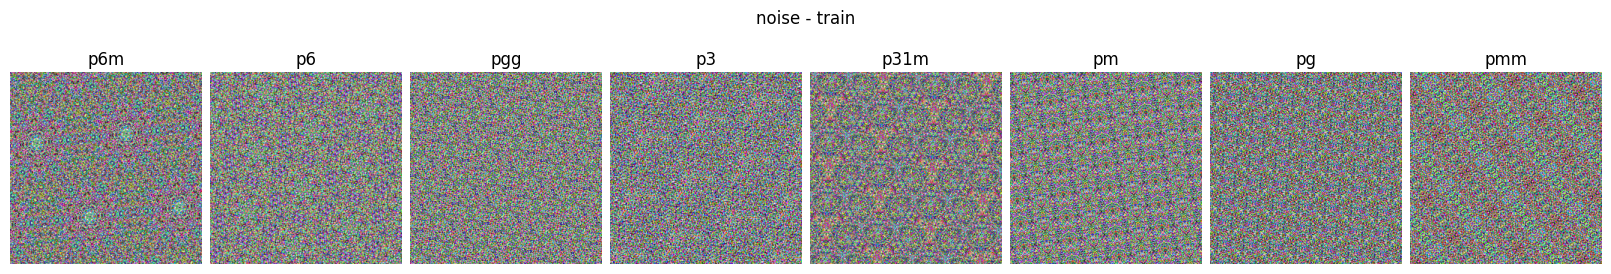

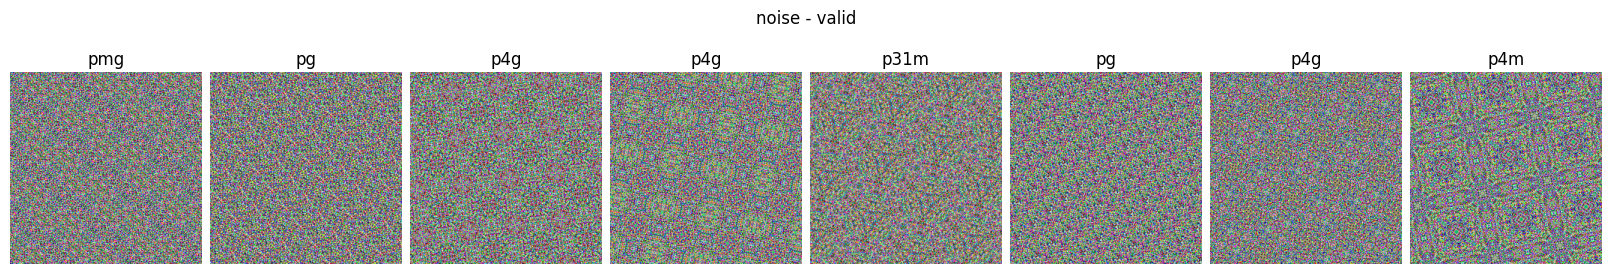

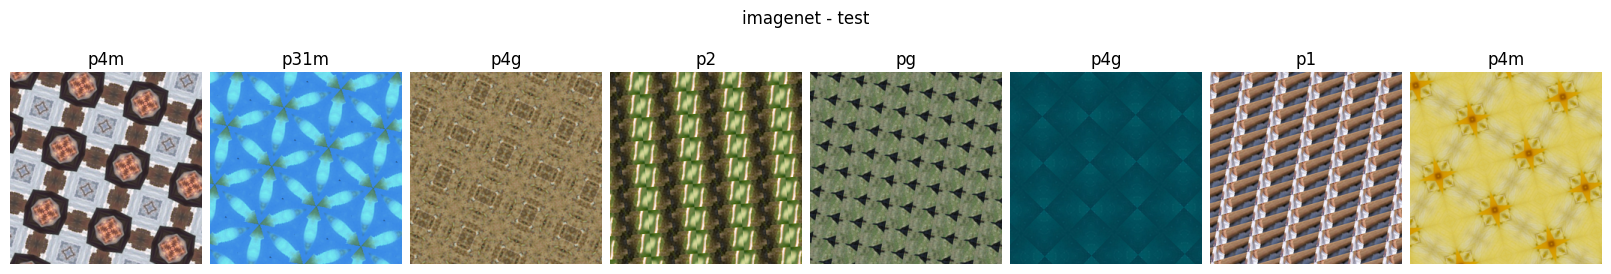

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

imagenet_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='noise', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

# imagenet - train
train_dl = DataLoader(train_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(train_dl, label_converter=label_converter, title='noise - train')

# imagenet - valid
valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(valid_dl, label_converter=label_converter, title='noise - valid')

# atom
test_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='imagenet', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(test_dl, label_converter=label_converter, title='imagenet - test')

In [3]:
model = resnet50_yichen(in_channels=3, n_classes=17, pretrained=False)
print(model(torch.randn(2,3,256,256)).shape)

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


torch.Size([2, 17])


# train

In [4]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'model': 'resnet50_yichen',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'Train_Noise-CrossValidate_ImageNet'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [5]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


100%|██████████| 136/136 [01:49<00:00,  1.25it/s]


Training: Loss: 2.7408, Accuracy: 10.9620%, Time: 1.8203mins


100%|██████████| 34/34 [00:12<00:00,  2.66it/s]


Validation : Loss : 2.5112, Accuracy: 14.0637%, Time: 0.21mins


...

Training: Loss: 0.0020, Accuracy: 99.9975%, Time: 1.8175mins


100%|██████████| 34/34 [00:12<00:00,  2.75it/s]


Validation : Loss : 0.7275, Accuracy: 86.5784%, Time: 0.21mins


100%|██████████| 167/167 [00:56<00:00,  2.93it/s]


Validation : Loss : 20.7593, Accuracy: 6.5860%, Time: 0.95mins


# analyze

In [6]:
from analysis_functions import confusion_matrix, plot_cm

ModuleNotFoundError: No module named 'analysis_functions'

In [ ]:
# model = torch.load('/scratch/yichen/models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-19.pt')

# NAME = 'benchmark-resnet50_from_scratch-v4_10m-05312023'
# symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
#                     'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']                  

In [ ]:
# device = torch.device('cuda:0')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-train_cm.npy', cm)

  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [00:48<00:00,  2.76it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,4632.0,4725.0,4698.0,4719.0,4686.0,4661.0,4739.0,4679.0,4694.0,4711.0,4724.0,4654.0,4725.0,4728.0,4763.0,4756.0,4706.0


Accuracy for these batches: 0.9999875


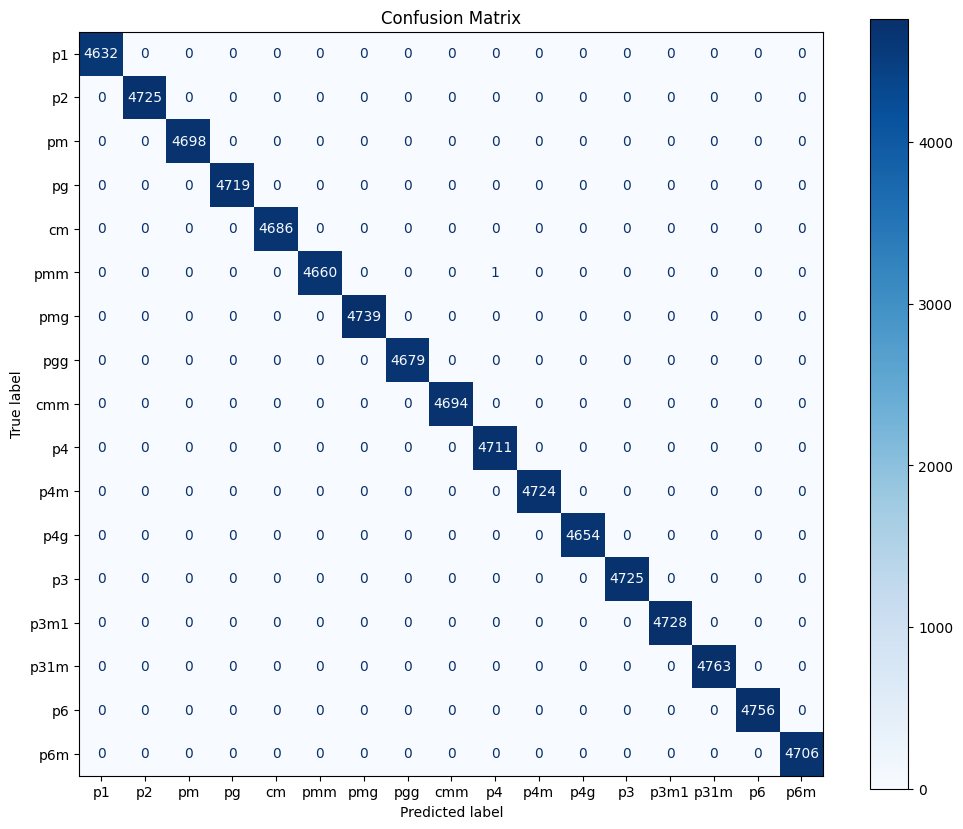

In [ ]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, title=None, style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-valid_cm.npy', cm)

  0%|          | 0/34 [00:00<?, ?it/s]

100%|██████████| 34/34 [00:12<00:00,  2.78it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,1249.0,1161.0,1184.0,1160.0,1195.0,1217.0,1142.0,1204.0,1191.0,1170.0,1158.0,1229.0,1157.0,1156.0,1117.0,1130.0,1180.0


Accuracy for these batches: 0.97765


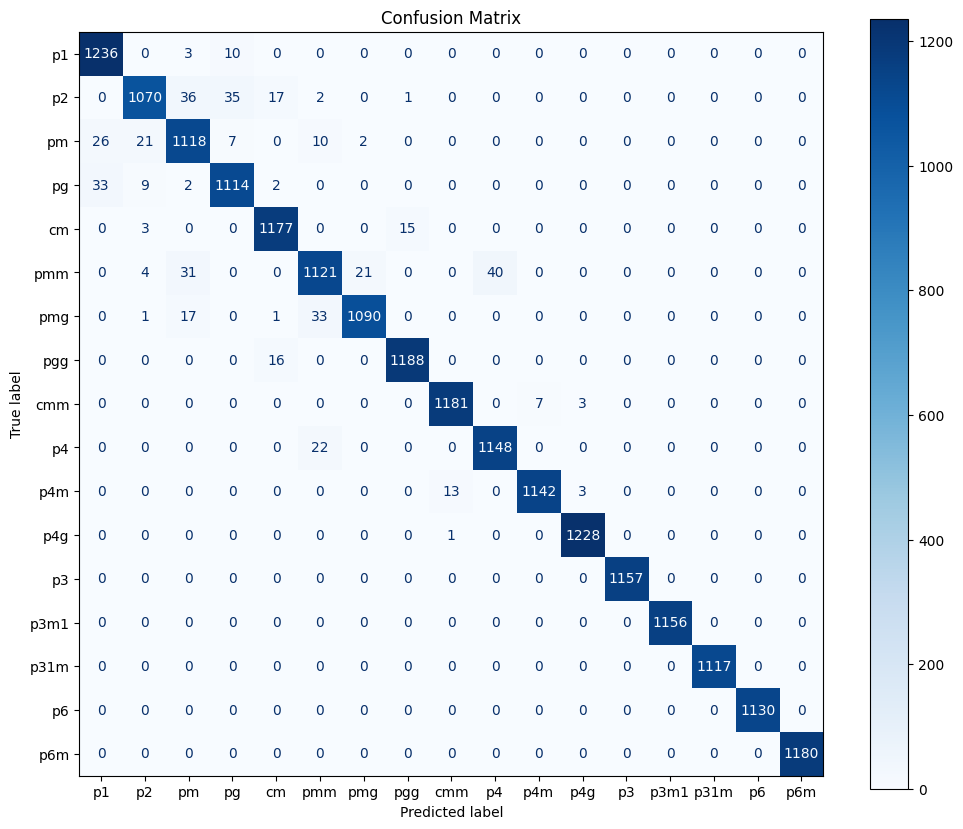

In [ ]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-test_cm.npy', cm)

NameError: name 'confusion_matrix' is not defined

In [ ]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

NameError: name 'plot_cm' is not defined